In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

print("Dataset Loaded Successfully!\n")

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Loaded Successfully!

Shape of Dataset:
(1277, 2)

First 5 Rows:


,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Back to Contents                                               1277 non-null   object
 1   Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)  1277 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB

Missing Values:
Back to Contents                                                 0
Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)    0
dtype: int64

Duplicate Rows:
0


In [3]:
df = df.iloc[2:].reset_index(drop=True)
df.columns = ["Date", "Production"]
df["Date"] = pd.to_datetime(df["Date"])
df["Production"] = pd.to_numeric(df["Production"])
df = df.sort_values("Date").reset_index(drop=True)

print("Data cleaned successfully!\n")

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Data cleaned successfully!

Shape: (1275, 2)

Data Types:
Date          datetime64[us]
Production             int64
dtype: object

First 5 Rows:


,Date,Production
0,1920-01-15,34008
1,1920-02-15,33193
2,1920-03-15,36171
3,1920-04-15,34945
4,1920-05-15,36622



Last 5 Rows:


,Date,Production
1270,2025-11-15,413677
1271,2025-12-15,423356
1272,2026-01-15,412456
1273,2026-02-15,383507
1274,2026-03-15,424566


In [4]:
df = df[df["Date"].dt.year >= 1980].reset_index(drop = True)
print("Filtered Data Sucessfully!")
print("Shape:", df.shape)
print("\nDate Range:")
print("Start:", df["Date"].min())
print("End  :", df["Date"].max())

display(df.head())

display(df.tail())

Filtered Data Sucessfully!
Shape: (555, 2)

Date Range:
Start: 1980-01-15 00:00:00
End  : 2026-03-15 00:00:00


,Date,Production
0,1980-01-15,268940
1,1980-02-15,252431
2,1980-03-15,269650
3,1980-04-15,260541
4,1980-05-15,267684


,Date,Production
550,2025-11-15,413677
551,2025-12-15,423356
552,2026-01-15,412456
553,2026-02-15,383507
554,2026-03-15,424566


In [6]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df["lag_1"] = df["Production"].shift(1)
df["lag_3"] = df["Production"].shift(3)
df["lag_6"] = df["Production"].shift(6)
df["lag_12"] = df["Production"].shift(12)

df["rolling_mean_3"] = df["Production"].rolling(window=3).mean()
df["rolling_mean_6"] = df["Production"].rolling(window=6).mean()
df["rolling_mean_12"] = df["Production"].rolling(window=12).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Feature Engineering Completed Successfully!\n")

print("Final Dataset Shape:", df.shape)

display(df.head())

Feature Engineering Completed Successfully!

Final Dataset Shape: (543, 11)


,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1981-01-15,264736,1,1981,266777.0,264489.0,264964.0,268940.0,262121.666667,261712.000000,261846.750000
1,1981-02-15,240914,2,1981,264736.0,254852.0,260841.0,252431.0,257475.666667,258390.833333,260887.000000
2,1981-03-15,267003,3,1981,240914.0,266777.0,258577.0,269650.0,257551.000000,259795.166667,260666.416667
3,1981-04-15,256708,4,1981,267003.0,264736.0,264489.0,260541.0,254875.000000,258498.333333,260347.000000
4,1981-05-15,263541,5,1981,256708.0,240914.0,254852.0,267684.0,262417.333333,259946.500000,260001.750000


In [7]:
print("Dataset Statistics:\n")
display(df.describe())
print("\n Correlation Matrix: \n")
display(df.corr(numeric_only=True))

Dataset Statistics:



,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
count,543,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,2003-08-15 11:53:22.209944,242411.837937,6.475138,2003.127072,242121.250460,241611.817680,240723.368324,239026.965009,242139.135052,241727.411909,240862.015654
min,1981-01-15 00:00:00,119208.000000,1.000000,1981.000000,119208.000000,119208.000000,119208.000000,119208.000000,137775.000000,144221.500000,150193.583333
25%,1992-04-30 00:00:00,179704.000000,3.000000,1992.000000,179704.000000,179704.000000,179704.000000,179704.000000,178018.000000,177851.750000,177985.791667
50%,2003-08-15 00:00:00,226801.000000,6.000000,2003.000000,226801.000000,226801.000000,226801.000000,226801.000000,225195.333333,225373.833333,225226.583333
75%,2014-11-30 00:00:00,275013.000000,9.000000,2014.000000,274457.000000,273958.000000,273280.500000,271594.500000,273179.166667,272889.583333,272524.708333
max,2026-03-15 00:00:00,429777.000000,12.000000,2026.000000,429777.000000,429777.000000,428114.000000,419427.000000,424245.333333,422449.166667,415362.583333
std,NaN,74609.338301,3.462347,13.075020,74204.758017,73599.559848,72370.102280,69991.422594,73864.337783,73217.644277,71827.137596



 Correlation Matrix: 



,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
Production,1.000000,0.015962,0.437077,0.983307,0.983187,0.971908,0.966978,0.994988,0.992659,0.986750
Month,0.015962,1.000000,-0.012585,-0.007668,-0.021436,-0.016695,0.014411,0.001797,-0.003378,-0.003730
Year,0.437077,-0.012585,1.000000,0.431085,0.419845,0.400211,0.358622,0.433618,0.425309,0.407075
lag_1,0.983307,-0.007668,0.431085,1.000000,0.985666,0.981342,0.956628,0.994160,0.992867,0.988726
lag_3,0.983187,-0.021436,0.419845,0.985666,1.000000,0.982919,0.967529,0.989319,0.993753,0.991649
lag_6,0.971908,-0.016695,0.400211,0.981342,0.982919,1.000000,0.970603,0.983135,0.987696,0.992706
lag_12,0.966978,0.014411,0.358622,0.956628,0.967529,0.970603,1.000000,0.967940,0.973335,0.982674
rolling_mean_3,0.994988,0.001797,0.433618,0.994160,0.989319,0.983135,0.967940,1.000000,0.998395,0.993921
rolling_mean_6,0.992659,-0.003378,0.425309,0.992867,0.993753,0.987696,0.973335,0.998395,1.000000,0.997380
rolling_mean_12,0.986750,-0.003730,0.407075,0.988726,0.991649,0.992706,0.982674,0.993921,0.997380,1.000000


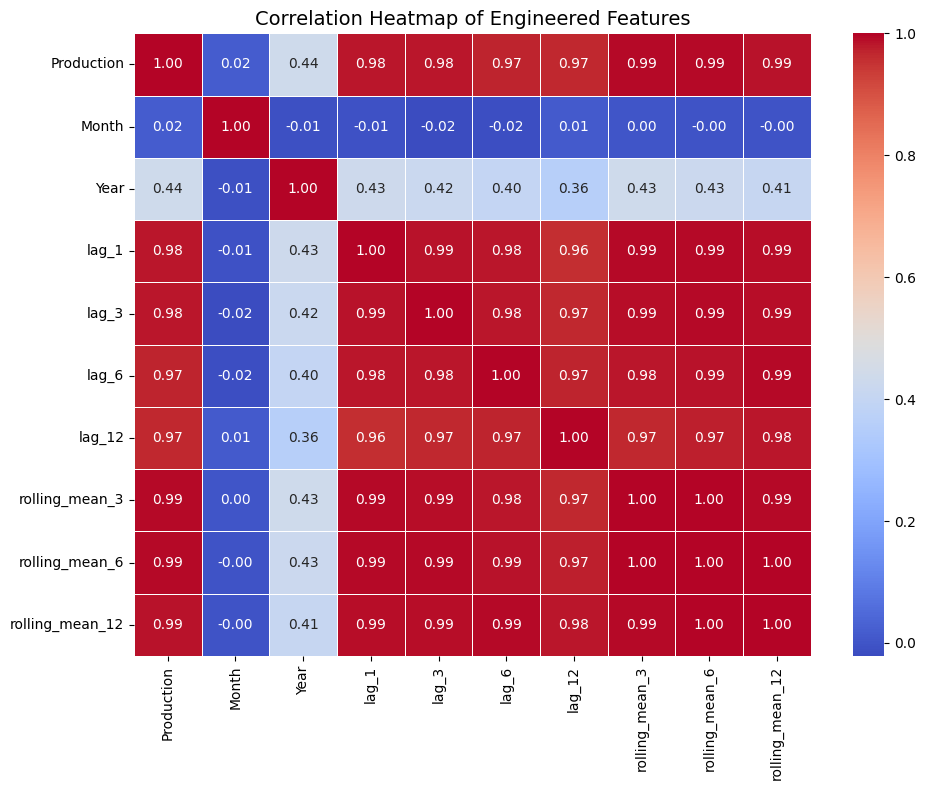

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidth =0.5
)
plt.title("Correlation Heatmap of Engineered Features", fontsize=14)
plt.tight_layout()
plt.savefig(
    "Correlation Heatmap.png",
    bbox_inches = "tight",
    dpi = 300
)
plt.show()

In [10]:
X = df.drop(columns=["Date", "Production"])

y = df["Production"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures Used:")
print(list(X.columns))

display(X.head())
display(y.head())

Feature Matrix Shape: (543, 9)
Target Shape: (543,)

Features Used:
['Month', 'Year', 'lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']


,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1,1981,266777.0,264489.0,264964.0,268940.0,262121.666667,261712.000000,261846.750000
1,2,1981,264736.0,254852.0,260841.0,252431.0,257475.666667,258390.833333,260887.000000
2,3,1981,240914.0,266777.0,258577.0,269650.0,257551.000000,259795.166667,260666.416667
3,4,1981,267003.0,264736.0,264489.0,260541.0,254875.000000,258498.333333,260347.000000
4,5,1981,256708.0,240914.0,254852.0,267684.0,262417.333333,259946.500000,260001.750000


0    264736
1    240914
2    267003
3    256708
4    263541
Name: Production, dtype: int64

In [11]:
split_index = int(len(df)*0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("Training Samples: ", len(X_train))
print("Testing Samples: ", len(X_test))
print("\nTraining Data Range: ")
print(df.iloc[:split_index]["Date"].min(), "to", df.iloc[:split_index]["Date"].max())
print("\nTesting Date Range:")
print(df.iloc[split_index:]["Date"].min(), "to", df.iloc[split_index:]["Date"].max())

Training Samples:  434
Testing Samples:  109

Training Data Range: 
1981-01-15 00:00:00 to 2017-02-15 00:00:00

Testing Date Range:
2017-03-15 00:00:00 to 2026-03-15 00:00:00


In [12]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling Completed Successfully!\n")

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)


Scaling Completed Successfully!

Training Shape : (434, 9)
Testing Shape  : (109, 9)


In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = mean_squared_error(y_test, lr_predictions) ** 0.5
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-" * 35)

print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
-----------------------------------
MAE  : 6709.00
RMSE : 10325.24
R²   : 0.9359


In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
ridge_params = {
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

ridge = Ridge()

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best CV Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best CV Score : 0.734170264101485


In [15]:
# ==========================
# Ridge Regression Hyperparameter Tuning
# ==========================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter Grid
ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Ridge Model
ridge = Ridge()

# Grid Search
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

# Train Grid Search
ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best Cross Validation R² :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best Cross Validation R² : 0.734170264101485


In [16]:
ridge_model = Ridge(alpha=ridge_grid.best_params_["alpha"])

ridge_model.fit(X_train_scaled, y_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = mean_squared_error(y_test, ridge_predictions) ** 0.5
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")
print("-" * 35)

print(f"MAE  : {ridge_mae:.2f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Results
-----------------------------------
MAE  : 6731.18
RMSE : 10407.02
R²   : 0.9349


In [18]:
from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        5,
        10
    ]
}

lasso = Lasso(max_iter=10000)

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", lasso_grid.best_params_)
print("Best Cross Validation R² :", lasso_grid.best_score_)

Best Alpha : {'alpha': 0.0001}
Best Cross Validation R² : 0.6805267471013746


In [19]:
lasso_model = Lasso(
    alpha=lasso_grid.best_params_["alpha"],
    max_iter=10000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = mean_squared_error(y_test, lasso_predictions) ** 0.5
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Results")
print("-"*35)

print(f"MAE  : {lasso_mae:.2f}")
print(f"RMSE : {lasso_rmse:.2f}")
print(f"R²   : {lasso_r2:.4f}")

Lasso Regression Results
-----------------------------------
MAE  : 6708.99
RMSE : 10325.23
R²   : 0.9359


In [20]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": lr_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

display(coef_df)

,Feature,Linear Regression,Ridge,Lasso
0,Month,438.389602,488.372560,438.391827
1,Year,490.867311,887.931079,490.867425
2,lag_1,-13821.802782,-9592.027387,-13821.839517
3,lag_3,5666.382313,3798.715562,5666.472976
4,lag_6,615.042503,-5914.303856,614.994671
5,lag_12,13020.873130,8613.699093,13020.825044
6,rolling_mean_3,56247.051109,43567.833251,56247.453947
7,rolling_mean_6,24725.397596,18002.577707,24724.660155
8,rolling_mean_12,-43812.309813,-15892.018129,-43811.933451


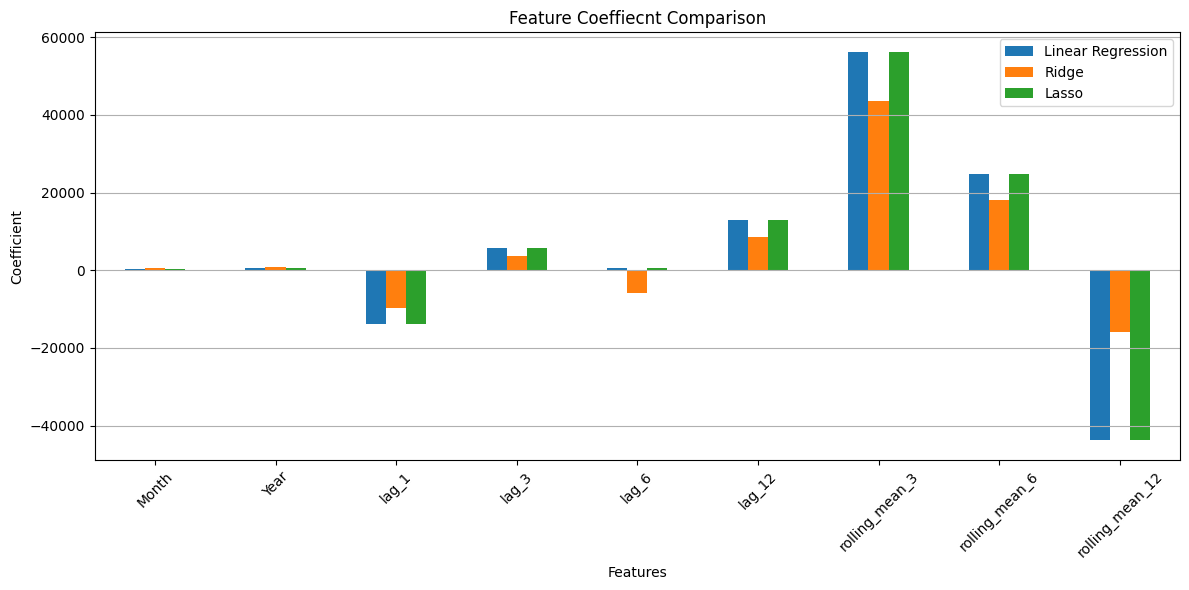

In [21]:
coef_df.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Feature Coeffiecnt Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    "Coefficient_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [23]:
# ==========================
# Elastic Net Hyperparameter Tuning
# ==========================

from sklearn.linear_model import ElasticNet

elastic_params = {
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10
    ],
    "l1_ratio": [
        0.2,
        0.4,
        0.5,
        0.6,
        0.8
    ]
}

elastic = ElasticNet(max_iter=10000)

elastic_grid = GridSearchCV(
    estimator=elastic,
    param_grid=elastic_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(elastic_grid.best_params_)

print("\nBest Cross Validation R²:")
print(elastic_grid.best_score_)

Best Parameters:
{'alpha': 0.1, 'l1_ratio': 0.8}

Best Cross Validation R²:
0.7157032958619427


In [28]:
elastic_model = ElasticNet(
    alpha=elastic_grid.best_params_["alpha"],
    l1_ratio=elastic_grid.best_params_["l1_ratio"],
    max_iter=10000
)

elastic_model.fit(
    X_train_scaled,
    y_train
)

elastic_predictions = elastic_model.predict(X_test_scaled)

elastic_mae = mean_absolute_error(
    y_test,
    elastic_predictions
)

elastic_rmse = mean_squared_error(
    y_test,
    elastic_predictions
) ** 0.5

elastic_r2 = r2_score(
    y_test,
    elastic_predictions
)

print("Elastic Net Results")
print("-"*35)

print(f"MAE  : {elastic_mae:.2f}")
print(f"RMSE : {elastic_rmse:.2f}")
print(f"R²   : {elastic_r2:.4f}")

Elastic Net Results
-----------------------------------
MAE  : 8859.63
RMSE : 13113.84
R²   : 0.8966


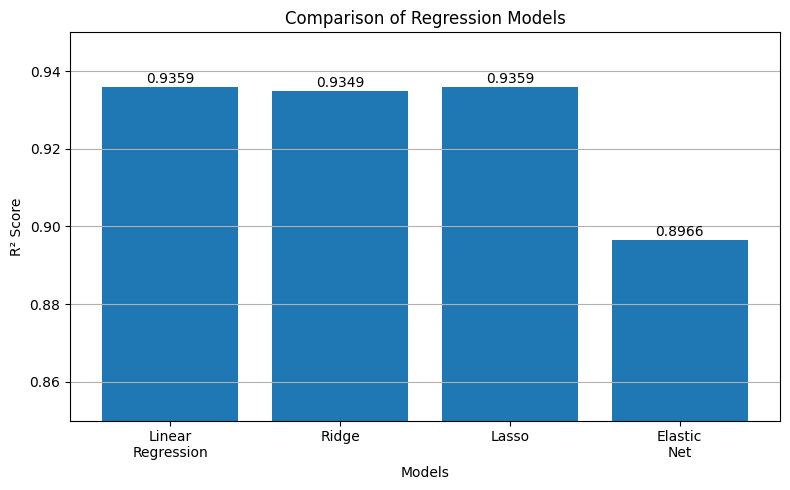

In [31]:
# ==========================
# Regression Model Comparison
# ==========================

import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Ridge",
    "Lasso",
    "Elastic\nNet"
]

r2_scores = [
    lr_r2,
    ridge_r2,
    lasso_r2,
    elastic_r2
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, r2_scores)

plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.ylim(0.85,0.95)

# Write R² value above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "Regression_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()